순수 궁금증으로 edf 포맷 파일 여는 것을 시도함. 오류가 많은 아주 날것의 방식이라서 중단했고, 
보다 정확한 방식은 MNE 라이브러리를 참고하며 조정한 코드를 사용하는 것임; asdf.ipynb (이름은 나중에 바꿔야 함)

In [ ]:
from pyedflib import highlevel
import numpy as np
import glob

# 모듈은 잘 실행됨. 시험 삼아 chb01 폴더의 edf 파일들을 불러와 시각화하기 - pyedflib, mne로 각각 실행.

채널 수: 23
채널 이름: ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8']
read -1, less than 921600 requested!!!


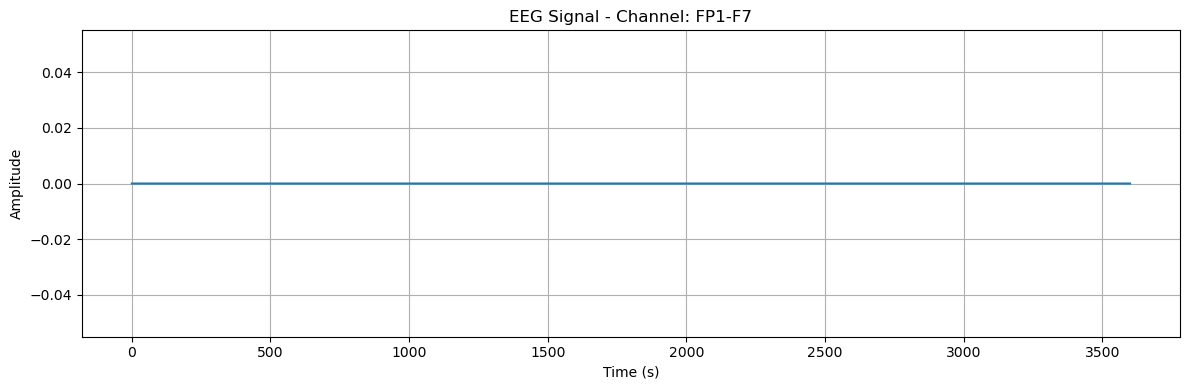

In [ ]:
'''
1. pyedflib로 시각화
import os
import pyedflib
import numpy as np
import matplotlib.pyplot as plt

# EDF 파일 경로 지정 (절대경로를 사용해야 인식됨;;)
edf_file = '/home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/database/physionet.org/files/chbmit/1.0.0/chb01/chb01_01.edf'

# EDF 파일 열기
f = pyedflib.EdfReader(edf_file)

# 채널 수 확인
n = f.signals_in_file
print(f"채널 수: {n}")

# 채널 이름 확인
labels = f.getSignalLabels()
print(f"채널 이름: {labels}")

# 첫 번째 채널 데이터 읽기 (예: 채널 0번)
ch_idx = labels.index("FP1-F7")
signal = f.readSignal(ch_idx)
signal_freq = f.getSampleFrequency(0)
duration = len(signal) / signal_freq
time = np.linspace(0, duration, len(signal))

# 시각화
plt.figure(figsize=(12, 4))
plt.plot(time, signal)
plt.title(f"EEG Signal - Channel: {labels[0]}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()

그래프에 파형이 전혀 안 그려짐. 
'''

불러오는 중: /home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/database/physionet.org/files/chbmit/1.0.0/chb23/chb23_19.edf
Extracting EDF parameters from /home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/database/physionet.org/files/chbmit/1.0.0/chb23/chb23_19.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 3686399  =      0.000 ... 14399.996 secs...


/tmp/ipykernel_7743/1949773949.py:18: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_file_23, preload=True)


Using matplotlib as 2D backend.


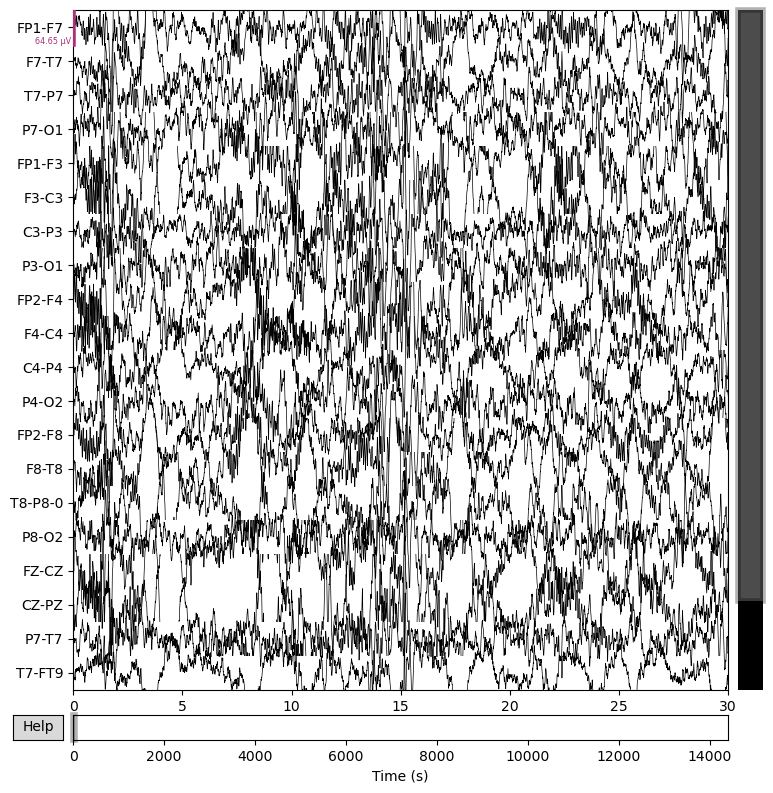

불러오는 중: /home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/database/physionet.org/files/chbmit/1.0.0/chb23/chb23_07.edf
Extracting EDF parameters from /home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/database/physionet.org/files/chbmit/1.0.0/chb23/chb23_07.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 655359  =      0.000 ...  2559.996 secs...


/tmp/ipykernel_7743/1949773949.py:18: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_file_23, preload=True)


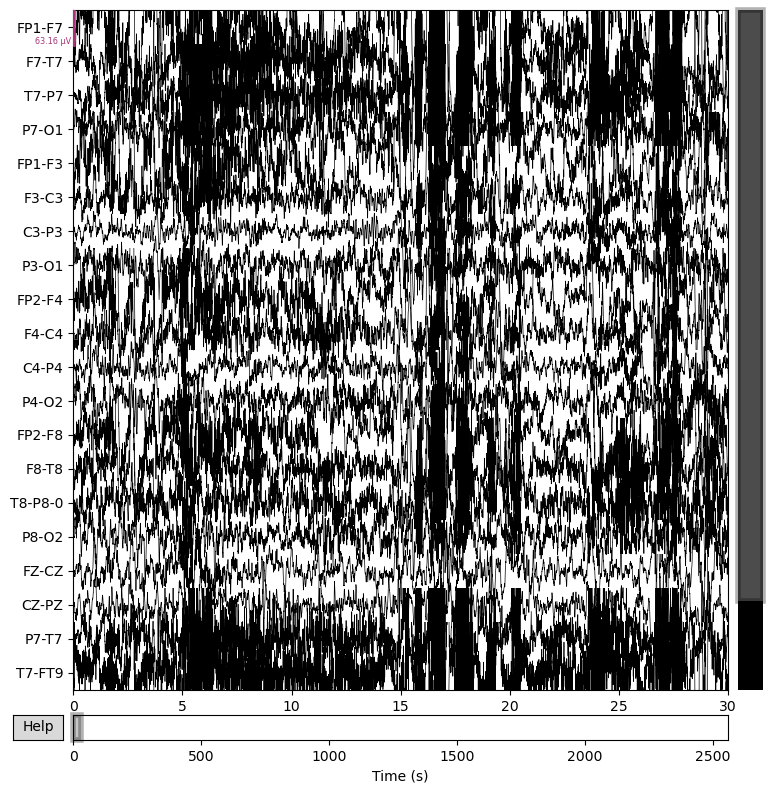

KeyboardInterrupt: Interrupted by user

In [12]:
# 2. mne로 시각화

# 라이브러리 불러오기
import os
import mne  # https://mne.tools/stable/auto_tutorials/raw/10_raw_overview.html#sphx-glr-auto-tutorials-raw-10-raw-overview-py
import glob
import matplotlib.pyplot as plt

# EDF 파일 경로 지정(절대경로 사용)
edf_file_23 = '/home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/database/physionet.org/files/chbmit/1.0.0/chb23'

# 2. 폴더 내 모든 .edf 파일 경로 가져오기 (파일당 4시간짜리인 23번 샘플의 초반 30초만 확인해보기, 연속된 파일은 9개)
edf_files_chb23 = glob.glob(os.path.join(edf_file_23, '*.edf'))

# 3. 반복하면서 각 파일 시각화
for edf_file_23 in edf_files_chb23:
    print(f"불러오는 중: {edf_file_23}")
    raw = mne.io.read_raw_edf(edf_file_23, preload=True)
    
    # 시각화 (예: 첫 30초, 자동 스케일링)
    raw.plot(duration=30, scalings='auto', title=os.path.basename(edf_file_23))
    
    # 사용자 입력으로 다음 파일 넘어가기 (엔터 키)
    input("▶ 다음 파일로 넘어가려면 Enter 키를 누르세요...\n")

In [ ]:
# 2. mne로 시각화 (MNE 공식 사이트: https://mne.tools/stable/auto_tutorials/raw/10_raw_overview.html#sphx-glr-auto-tutorials-raw-10-raw-overview-py) 

# 라이브러리 불러오기
import os

import matplotlib.pyplot as plt
import numpy as np

import mne

# EDF 파일 경로 지정(절대경로 사용)
edf_file_23 = '/home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/database/physionet.org/files/chbmit/1.0.0/chb23'

# 2. 폴더 내 모든 .edf 파일 경로 가져오기 (파일당 4시간짜리인 23번 샘플의 초반 30초만 확인해보기, 연속된 파일은 9개)
edf_files_chb23 = glob.glob(os.path.join(edf_file_23, '*.edf'))

# 3. 반복하면서 각 파일 시각화
for edf_file_23 in edf_files_chb23:
    print(f"불러오는 중: {edf_file_23}")
    raw = mne.io.read_raw_edf(edf_file_23, preload=True)
    
    # 시각화 (예: 첫 30초, 자동 스케일링)
    raw.plot(duration=30, scalings='auto', title=os.path.basename(edf_file_23))
    
    # 사용자 입력으로 다음 파일 넘어가기 (엔터 키)
    input("▶ 다음 파일로 넘어가려면 Enter 키를 누르세요...\n")

Extracting EDF parameters from /home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/database/physionet.org/files/chbmit/1.0.0/chb01/chb01_03.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/tmp/ipykernel_7743/1089158683.py:10: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_file_01_03, preload=True)


<Info | 8 non-empty values
 bads: []
 ch_names: FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3, C3-P3, P3-O1, ...
 chs: 23 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2076-11-06 13:43:04 UTC
 nchan: 23
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: Surrogate>
>
채널 이름: ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']


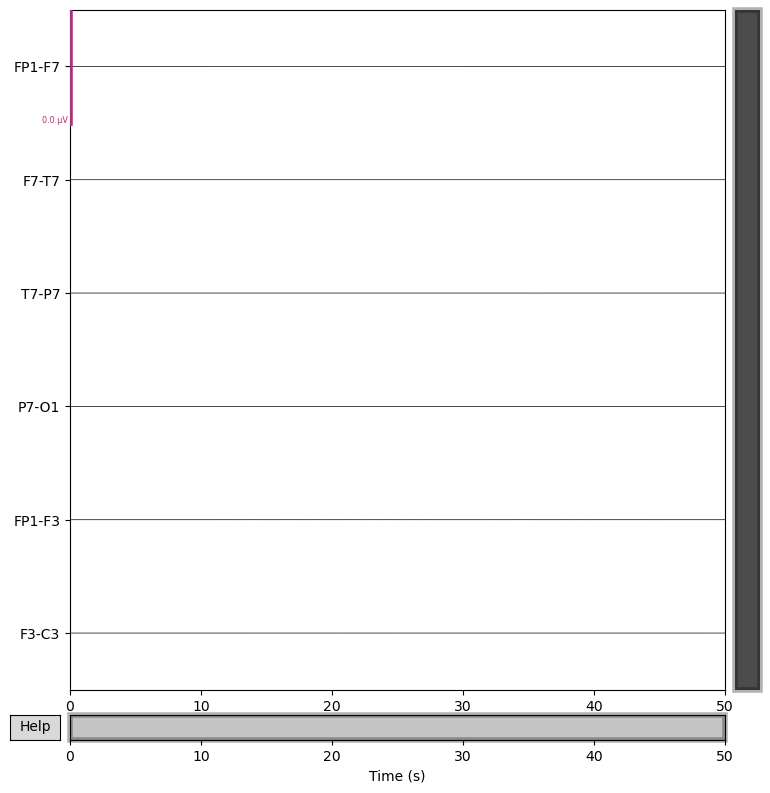

In [ ]:
# 단일한 edf 파일 시각화

import mne
import matplotlib.pyplot as plt

# EDF 파일 경로 지정
edf_file_01_03 = '/home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/database/physionet.org/files/chbmit/1.0.0/chb01/chb01_03.edf'

# EDF 파일 읽기
raw = mne.io.read_raw_edf(edf_file_01_03, preload=True)

# 기본 정보 출력
print(raw.info)

# 채널 이름 확인
print("채널 이름:", raw.ch_names)

# 시각화 1 (전체 채널 파형)
raw.plot(n_channels=10, duration=10, scalings='auto', title='EEG Signals')

# 시각화 2 (특정 채널 파형)
#raw.plot(picks=["채널명1", "채널명2"], duration=10, scalings='auto')  #채널 명 예시: ["FP1-F7", "F7-T7"]
#plt.show()


In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)

2.7.0+cu128
True
12.8


In [2]:
# .seizure 파일 열기
import os
import wfdb
import mne

ann = wfdb.rdann('/home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/physionet.org/files/chbmit/1.0.0/chb01/chb01_03', 'edf.seizure', sampfrom=0, sampto=10000)

FileNotFoundError: [Errno 2] No such file or directory: '/home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/physionet.org/files/chbmit/1.0.0/chb01/chb01_03.edf.seizure'